# Imports

In [1]:
import numpy as np
import pandas as pd
import bincatsim as bs
import astropy.units as u
from matplotlib import pyplot as plt
from scipy.signal import argrelextrema
from importlib import reload
from tqdm import tqdm

import grasp as gp
stats = gp.stats

home = '/home/pietrof'

lf = gp.plots.label_font
lf['size'] = 18

tf = gp.plots.title_font
tf['size'] = 22

df = pd.read_csv(bs.paths.SIM_RECORD_FILE)

sd = df[['20260528_' not in x for x in df['TN']]]
sd2 = df[['20260528_' in x for x in df['TN']]]


[XuPy] Device 0 available - GPU : `NVIDIA GeForce RTX 5080 Laptop GPU`
       Memory = 16220.22 MB | Compute Capability = 12.0
       Using CuPy 13.6.0 for acceleration.


/home/pietrof/miniforge3/envs/bincat/lib/python3.13/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [2]:
def plot_groups(
    data,
    x,
    y,
    hue:str = None,
    xlabel: str = None,
    ylabel: str = None,
    title : str =None,
    **kwargs
):
    fs = kwargs.pop('figsize', (10,8))
    lon = kwargs.pop('legend', True)
    yscale = kwargs.pop('yscale', None)
    if hue is not None:
        if isinstance(hue, str) and hue in data.columns:
            data = {dm: data[data[hue] == dm] for dm in data[hue].unique()} if hue else data
        else:
            try:
                data = {0: data[hue]}
                lon = False
            except Exception as e:
                print(f"Error processing hue: {e}")
                data = {0: data}
                lon = False
    else:
        data = {0: data}
        lon = False

    plt.figure(figsize=fs)
    for dm, group in data.items():
        plt.plot(group[x], group[y], '-o', label=f'{hue} = {float(dm):.2}', alpha=0.7, **kwargs)
    plt.xlabel(xlabel or x, fontdict=gp.plots.label_font)
    plt.ylabel(ylabel or y, fontdict=gp.plots.label_font)
    plt.title(title or f"{y.upper()} vs {x.upper()}", fontdict=gp.plots.title_font)
    plt.grid(linestyle='--', alpha=0.5)
    if lon:
        plt.legend(title='HUE', loc='best', fontsize='large')
    if yscale:
        plt.yscale(yscale)
    plt.tick_params(axis='both', labelsize=14)
    plt.show()
    

### Formule

\begin{align}

    \text{Chi Squared} & : & \chi^2 = \sum_i {\frac{(x_i - X)^2}{\sigma_{x_i}}} \\

    \text{Reduced Chi Squared} & : & \chi^2_\nu = \frac{\chi^2}{\nu} \quad ; \quad \text{with } \nu = N - P \\

    \text{Goodness-of-Fit} & : & F2 = \sqrt{\dfrac{9\nu}{2}}\bigg[\bigg(\underset{\chi^2_\nu}{\underbrace{\dfrac{\chi^2}{\nu}}}\bigg)^{1/3} + \dfrac{2}{9\nu} - 1 \bigg] \\

    \text{log GoF Harmonic Decomposition} & : & \log{F2}(\varphi) \simeq c_0 + \sum_{k=1}^\infty{c_k\cos{(2k\,\varphi)} + s_k\sin{(2k\,\varphi)}} \\

    \text{\texttt{ipd\_gof\_harmonic\_amplitude}} & : & A_{ipd} = \sqrt{c_2^2 + s_2^2}  \\

    \text{\texttt{ipd\_gof\_harmonic\_phase}} & : & \varphi_{ipd} = \frac{1}{2} \arctan2{(c_2,s_2)} \\

\end{align}

# Bulk Simulations analysis

### Visualizations

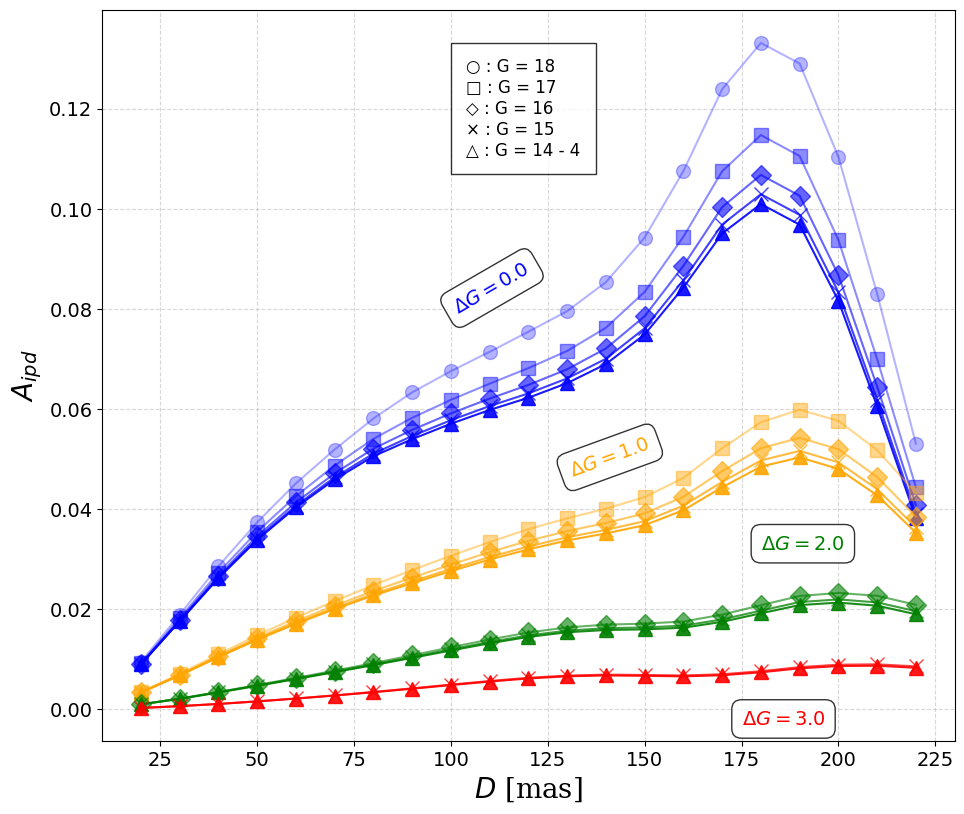

In [23]:
dat0 = sd[sd['delta_m'] == 0.0]
dat1 = sd[sd['delta_m'] == 1.0]
dat2 = sd[sd['delta_m'] == 2.0]
dat3 = sd[sd['delta_m'] == 3.0]

data = [dat0, dat1, dat2, dat3]
colors = ['blue', 'orange', 'green', 'red']

class MarkerObj:
    def __init__(self, code, text):
        self.code = code      # matplotlib marker code
        self.text = text      # text symbol for annotations/labels

    def __str__(self):
        return self.code

markers = [
    MarkerObj('^', '△'),
    MarkerObj('x', '×'),
    MarkerObj('D', '◇'),
    MarkerObj('s', '□'),
    MarkerObj('o', '○'),
    MarkerObj('v', '▽'),
]

fig, ax = plt.subplots(figsize=(11,9.5))
for i, dat in enumerate(data):
    ddd = {dm: dat[dat['G'] == dm] for dm in dat[dat['G'] >= 14]['G'].unique()}
    alpha = 0.9
    j=0
    for dm, group in ddd.items():
        ax.plot(group['D_mas'], group['gof_amp'], f'-{markers[j]}', color=colors[i], alpha=alpha, markersize=10)
        alpha -= 0.15
        j+=1

lf = gp.plots.label_font.copy()
lf['size'] = 20

ax.set_xlabel(r"$D$ [mas]", fontdict=lf)
ax.set_ylabel(r"$A_{ipd}$", fontdict=lf)
ax.tick_params(axis='both', labelsize=14)
# ax.set_title(r"$A_{ipd}(D)$ for different $\Delta M_G$", fontdict={'fontsize': 18})
ax.grid(linestyle='--', alpha=0.5)
bbox = {'boxstyle': 'round,pad=0.5', 'facecolor': 'white', 'alpha': 0.8}
ax.text(175, -1e-6, r'$\Delta G = 3.0$', fontsize=14, verticalalignment='top', color='red', bbox=bbox)
ax.text(180, 0.035, r'$\Delta G = 2.0$', fontsize=14, verticalalignment='top', color='green', bbox=bbox)
ax.text(130, 0.055, r'$\Delta G = 1.0$', fontsize=14, verticalalignment='top', color='orange', bbox=bbox, rotation=20)
ax.text(100, 0.09, r'$\Delta G = 0.0$', fontsize=14, verticalalignment='top', color='blue', bbox=bbox, rotation=30)
# ax.arrow(x=125, y=0.13, dx=0, dy=-0.03, head_width=3, head_length=0.005, fc='black', ec='black')
# ax.text(125, 0.135, f"G = {gmax:.0f}", fontsize=12, ha='center', va='center')
# ax.text(125, 0.090, f"G = {gmin:.0f}", fontsize=12, ha='center', va='center')
# ax.text(130, 0.115, 'Decreasing $G$', fontsize=13, verticalalignment='center', rotation=90, color='black')

ddd = {dm: dat0[dat0['G'] == dm] for dm in dat0[dat0['G'] >= 14]['G'].unique()}
Gs = sorted(ddd.keys())
bbox2 = {'boxstyle': 'square,pad=0.9', 'facecolor': 'white', 'alpha': 0.8}
text = f"""{markers[4].text} : G = {Gs[-1]:.0f}
{markers[3].text} : G = {Gs[-2]:.0f}
{markers[2].text} : G = {Gs[-3]:.0f}
{markers[1].text} : G = {Gs[-4]:.0f}
{markers[0].text} : G = {Gs[-5]:.0f} - 4"""
ax.text(104, 0.12, text, fontsize=12,horizontalalignment='left', verticalalignment='center', bbox=bbox2)

plt.show()

fig.savefig(f'{home}/Desktop/A_D_DM_G.png', dpi=450)

## IPD Parameter Determination

### $\chi^2_\nu$ TEST (CLOSED)

The ratio between the two methods of computing the reduced chi squared $\chi^2_{\nu}$ depend only on the number of degrees of freedom $\nu = N - P$, where, for fixed P, only depends on N, for which

- $N_c$ : cube lenght, i.e the number of observation for the given simulation (tn)
- $N_p$ : the lenght of the PSF itipd, which is a fixed number (n pixel)

**CONFIRMED**

$$\bigg\lt \dfrac{N_c}{N_{psf}} - \dfrac{\chi^2_\nu(N_c)}{\chi^2_\nu(N_{psf})} \bigg\gt = 4\cdot10^{-3} \pm 10^{-16} $$

In [ ]:
mr = []
N = []
for _, row in sd.iterrows():
    
    tn = row.TN
    ipd = bs.ipd_.IPD(tn=tn)
    chi2_infor = ipd._compute_chi2()

    chi2_og = []
    _phi = []
    for psfd in ipd.cube:
        psf = psfd.psf_2d
        chi2_og.append(bs.ipd_._reduced_chi_squared(psf, ipd.calibration.psf_2d))
        _phi.append(psfd.phi)

    chiphi = np.array(list(zip(chi2_og, _phi)))
    chi2_og = chiphi[np.argsort(chiphi[:,1])][:,0]

    ratio = chi2_og/chi2_infor
    mr.append(ratio.mean())
    N.append((len(ipd.cube), np.size(ipd.cube[0].psf_2d)))

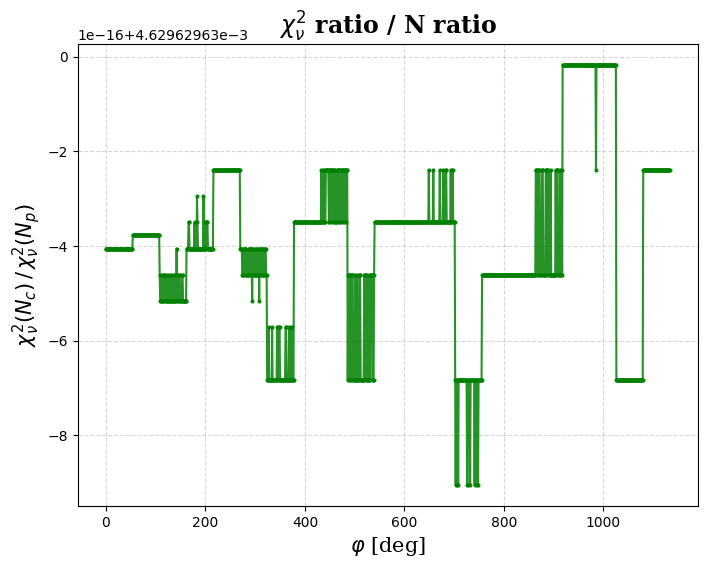

1.8423239040124414e-16


In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot((N[:,0]/N[:,1])[:-2] - mr[:-2], '-o', c='green', alpha=0.85, markersize=2)
ax.set_xlabel(r'$\varphi$ [deg]', fontdict=gp.plots.label_font)
ax.set_ylabel(r'$\chi^2_\nu(N_c) \, / \, \chi^2_\nu(N_p)$', fontdict=gp.plots.label_font)
ax.set_title(r'$\chi^2_\nu$ ratio / N ratio', fontdict=gp.plots.title_font)
ax.grid(linestyle='--', alpha=0.5)
plt.show()

print(np.std((N[:,0]/N[:,1])[:-2] - mr[:-2]))

## ipd_frac_multi_peak

We can combine the information of the $\mathrm{ipd\_frac\_multi\_peak}$ with the reduced chi squared in the AL direction $\chi^2_{\nu}(AL)$ to have a better estimate of the expected peak incidence

Given the PSFCube $PSF$ and it's computed $\mathrm{ipd\_frac\_multi\_peak}$ $M_{ipd}$, we fit its distribution with a quadratic polynomial $ax^2 + bx + c$ to find the minimum to use as threshold for considering a single $PSF_i$ a bad-fit to the calibration psf $PSF_C$

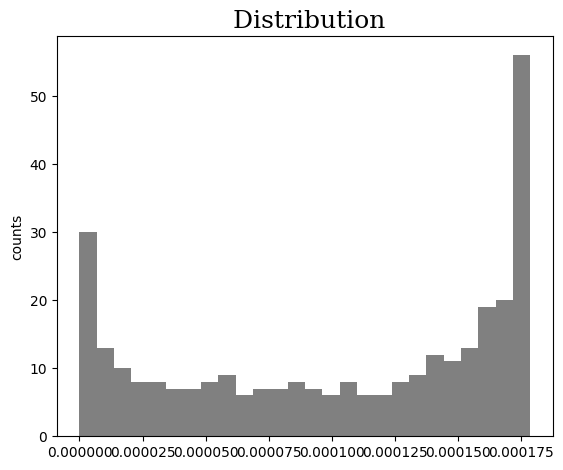

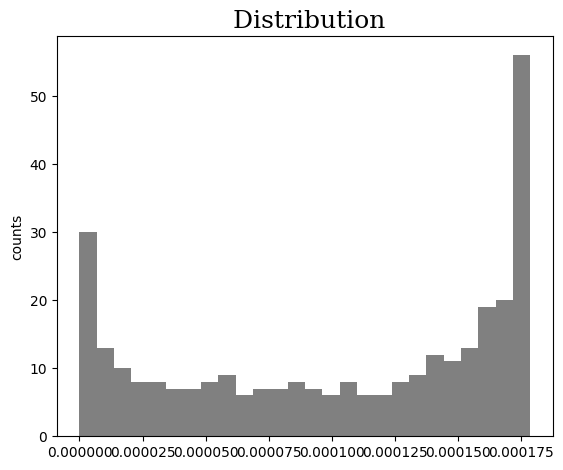

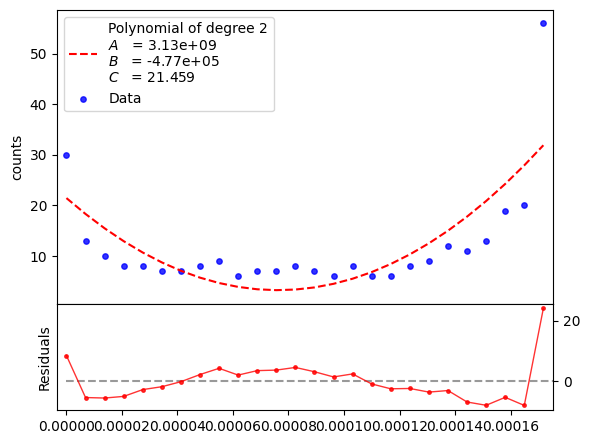

(<Figure size 640x520 with 2 Axes>,
 <Axes: ylabel='counts'>,
 <Axes: ylabel='Residuals'>)

In [3]:
cube = bs.load_psf(tn_or_fp=sd[(sd['D_mas'] == 200) & (sd['delta_m'] == 0.0)].iloc[0].TN)
repr(cube)

ipd = bs.ipd_.IPD(cube=cube, fitted_parameters=2)
ipd(verbose=False)

h = gp.plots.histogram(ipd.chi2_al, out=True, bins='detailed', dont_show=True)['h']

hp = h['counts']
hp_x = h['bins']

polyfit = stats.fit_data_points(hp, x_data=hp_x, method='poly2', plot=False)

gp.plots.regressionPlot(polyfit, size=15, f_type='datapoint', grid=True, pc='blue')

Phi at chi2 threshold: 57.51 degrees (195)


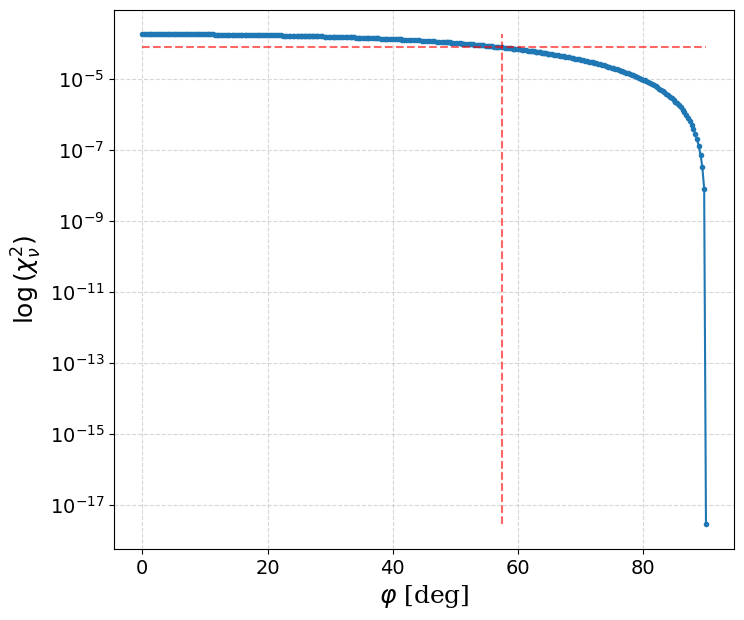

In [4]:
minim = argrelextrema(polyfit.y, np.less)
ythresh = polyfit.x[minim]

eps = 1e-6
for k, chival in enumerate(ipd.chi2_al):
    if abs(chival - ythresh) < eps:
        print(f"Phi at chi2 threshold: {ipd.phi[k]:.2f} degrees ({k})")
        break

phithresh = ipd.phi[k]

plt.figure(figsize=(8,7))
plt.plot(ipd.phi, ipd.chi2_al, '-o', markersize=3)
plt.plot([0,90],[ythresh,ythresh], '--', c='red', alpha=0.6)
plt.plot([phithresh,phithresh],[ipd.chi2_al.min() , ipd.chi2_al.max()], '--', c='red', alpha=0.6)
plt.yscale('log')
plt.xlabel(r'$\varphi$ [deg]', fontdict=gp.plots.label_font)
plt.ylabel(r'$\log{(\chi^2_\nu)}$', fontdict=gp.plots.label_font)
plt.tick_params(axis='both', labelsize=14)
plt.grid(linestyle='--', alpha=0.5)

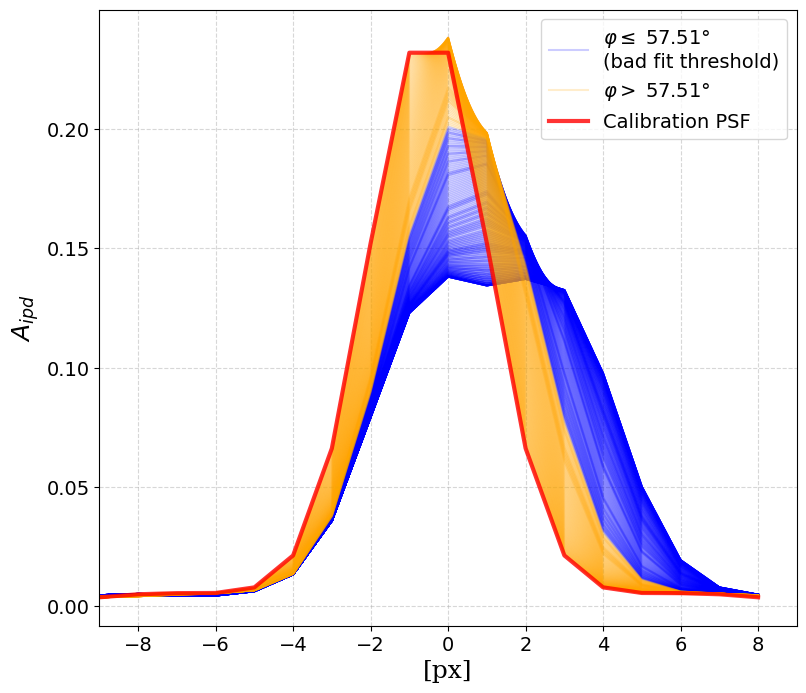

In [5]:
fig, ax = plt.subplots(figsize=(9,8))

half = len(ipd.calibration.psf_al) // 2
x = np.arange(-half, half)

for j, psfd in enumerate(cube):
    psf = psfd.psf_al
    if psfd.phi <= phithresh:
        ax.plot(x, psf, alpha=0.2, c='blue', label=r'$\varphi \leq$ {:.2f}°'.format(phithresh)+"\n(bad fit threshold)" if j == 0 else None)
    else:
        ax.plot(x, psf, alpha=0.2, c='orange', label=r'$\varphi >$ {:.2f}°'.format(phithresh) if j == len(cube) - 1 else None)
ax.plot(x, ipd.calibration.psf_al, c='red', label='Calibration PSF', linewidth=3, alpha=0.8)

ax.set_xlim(-half, half)
ax.set_xlabel(r"[px]", fontdict=gp.plots.label_font)
ax.set_ylabel(r"$A_{ipd}$", fontdict=gp.plots.label_font)
ax.tick_params(axis='both', labelsize=14)
ax.grid(linestyle='--', alpha=0.5)
ax.legend(loc='best', fontsize=14)
plt.show()

### Results

```python
try: 
    ipd_frac_badfit = []
    chithresh = []
    phithresh = []

    for row in tqdm(sd.itertuples(), total=len(sd), desc="Simulations"):
        ipd = bs.ipd_.IPD(tn=row.TN, fitted_parameters=2)
        ipd()
        
        ipd_frac_badfit.append(ipd.frac_badfit)
        chithresh.append(ipd._chi2_threshold)
        phithresh.append(ipd._phi_threshold)

    sd['frac_badfit'] = ipd_frac_badfit
    sd['chi2_threshold'] = chithresh[0]
    sd['phi_threshold'] = phithresh

except KeyboardInterrupt:
    print("Process interrupted by user.")

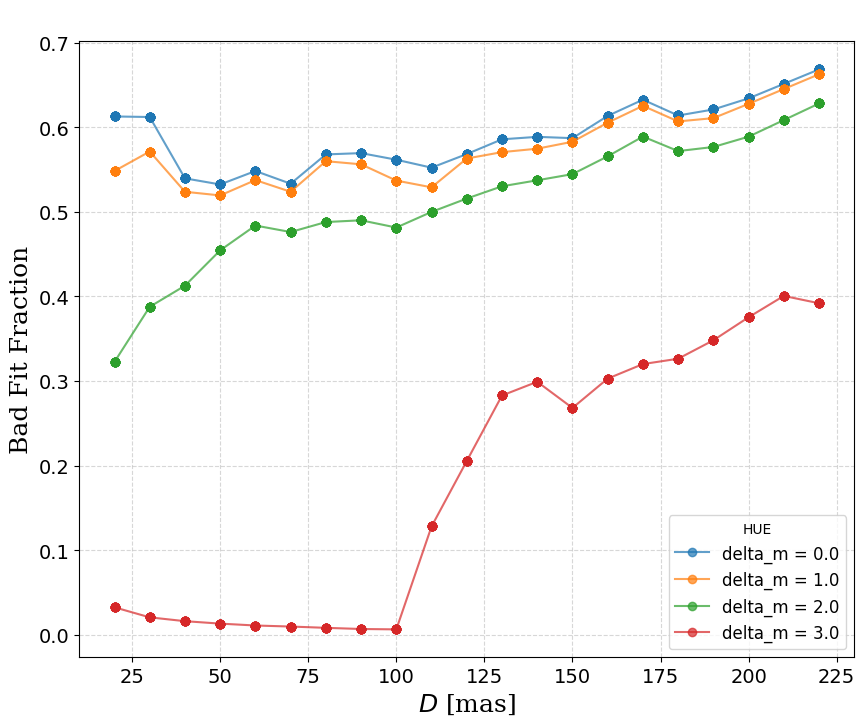

In [17]:
plot_groups(
    sd,
    x='D_mas',
    y='frac_badfit', 
    hue='delta_m',
    xlabel=r"$D$ [mas]", 
    ylabel=r"Bad Fit Fraction",
    title=' ', 
    figsize=(10,8),
    legend=True,
    #yscale='log'
)

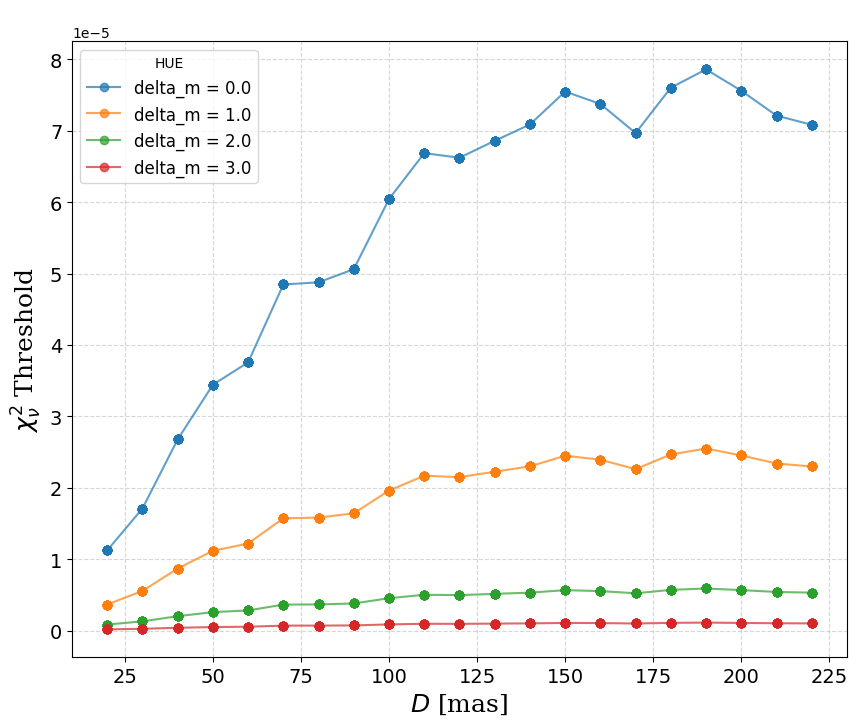

In [18]:
plot_groups(
    sd,
    x='D_mas',
    y='chi2_threshold', 
    hue='delta_m',
    xlabel=r"$D$ [mas]", 
    ylabel=r"$\chi^2_\nu$ Threshold",
    title=' ', 
    figsize=(10,8),
    legend=True,
    #yscale='log'
)

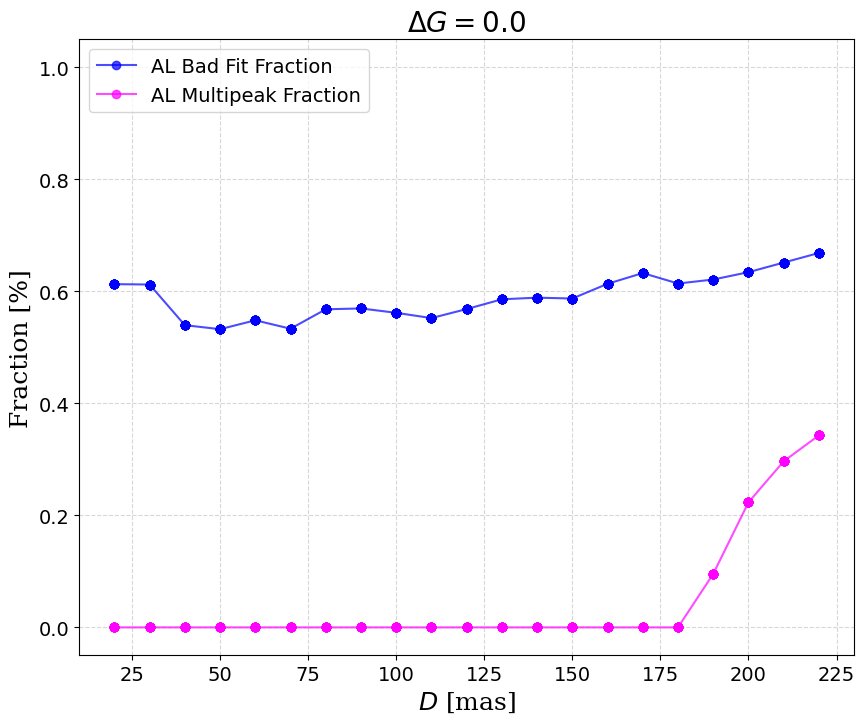

In [15]:
data = sd[sd['delta_m'] == 0.0]

x = data['D_mas']
y0 = data['frac_badfit']
y1 = data['al_multipeak']

fig = plt.figure(figsize=(10,8))
plt.plot(x, y0, '-o', label='AL Bad Fit Fraction', color='blue', alpha=0.7)
plt.plot(x, y1, '-o', label='AL Multipeak Fraction', color='magenta', alpha=0.7)
plt.xlabel(r"$D$ [mas]", fontdict=gp.plots.label_font)
plt.ylabel(r"Fraction [%]", fontdict=gp.plots.label_font)
plt.title(r"$\Delta G = 0.0$", fontdict={'size': 20})
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(-0.05, 1.05)
plt.grid(linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=14)

fig.savefig(f"{home}/Desktop/badfit_multipeak.png", dpi=450)

## Prove Varie

findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


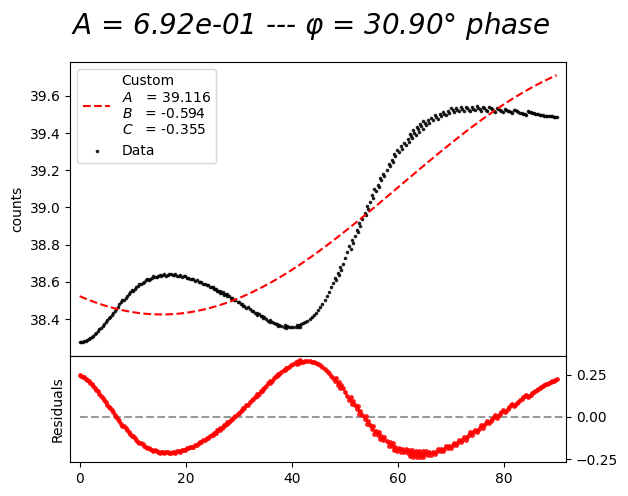

(<Figure size 640x520 with 2 Axes>,
 <Axes: ylabel='counts'>,
 <Axes: ylabel='Residuals'>)

In [61]:
cube = bs.load_psf(tn_or_fp=sd[(sd['D_mas'] == 200) & (sd['delta_m'] == 0.0)].iloc[0].TN)

dof = np.size(cube[0].psf_2d) - 1  # degrees of freedom for reduced chi-squared

chi2 = []
phi = []
for psfd in cube:
    psf = psfd.psf_2d
    exp = ipd.calibration.psf_2d
    
    chi2.append(np.sum(((psf-exp)**2)/(exp))/dof)
    phi.append(psfd.phi)

chiphi = np.array(list(zip(chi2, phi)))
chiphi = chiphi[np.argsort(chiphi[:, 1])]

gof = (9*dof / 2)**0.5 * (- 1 + 2/(9*dof) + chiphi[:,0]**(1/3))

y = np.log(chiphi[:,0])
X = chiphi[:,1]

fit = stats.fit_data_points(
    data=y,
    x_data=X,
    method=bs.ipd_.harmonic_decomposition(order=1),
)
_, c2, s2, *__ = fit.coeffs

gof_amp = np.sqrt(c2**2 + s2**2)
gof_phase = np.arctan2(s2, c2) * u.rad.to(u.deg) % 180

gp.plots.regressionPlot(fit, f_type='datapoint', title=rf"A = {gof_amp:.2e} --- $\varphi$ = {gof_phase:.2f}° phase")

findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


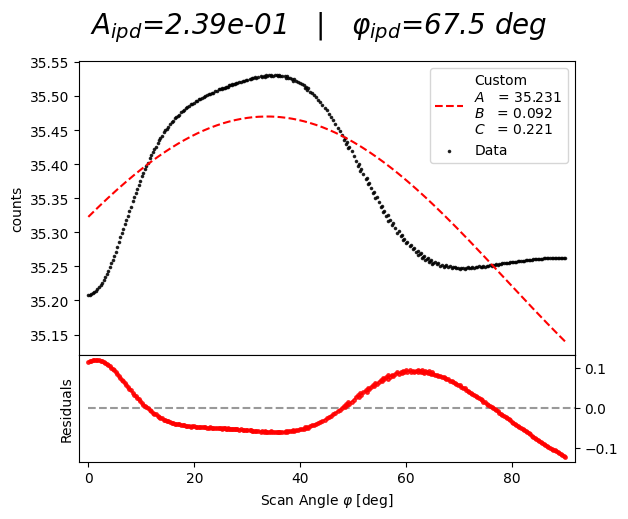

In [58]:
ipd = bs.ipd_.IPD(cube=cube, fitted_parameters=1)
ipd.harmonic_fit()

ipd.show_harmonic_fit()